In [4]:
import tempfile
import pickle
import sys
import traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from pprint import pprint

from one.api import ONE
from scipy.special import logit, softmax
import os
import scipy.stats as stats
from os.path import join
import pickle as pkl
from brainwidemap.bwm_loading import bwm_query, bwm_units, load_trials_and_mask, merge_probes
import bambi as bmb
import arviz as az
import numpy as np

import concurrent.futures
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
import sys

from one.api import ONE
from brainbox.io.one import SessionLoader
from iblatlas.atlas import BrainRegions
from sklearn.metrics import balanced_accuracy_score

from brainwidemap.bwm_loading import (
    bwm_query,
    load_good_units,
    load_trials_and_mask,
    merge_probes,
    bwm_units,
)
import numpy as np
import pandas as pd
from scipy.stats import linregress
import seaborn as sns

### Find valid sessions

In [ ]:
df = bwm_query()

In [ ]:
df['eid'].unique()[0]

In [ ]:
eid = df['eid'][0]

In [ ]:
eids = df['eid'].unique()

In [ ]:
qc = {}
for eid in eids:
    qc[eid] = [np.nan, True]

In [ ]:
a = pd.DataFrame.from_dict(qc, orient='index', columns=['contrast','feedback'])

In [ ]:
a.to_parquet

In [ ]:
engagement_df = pd.read_parquet('../data/external/merged_behavioral_and_states.pqt')

In [ ]:
one = ONE()
# one.load_cache()

In [ ]:
sess = SessionLoader(one, eid)

In [ ]:
sess.load_pupil()

In [ ]:
tx, mask = load_trials_and_mask(one, eid)

In [ ]:
engagement_df

In [ ]:
engagement_df_eid = engagement_df[engagement_df['eid']==eid].reset_index(drop=True)

In [ ]:
tx_ew = tx.merge(engagement_df_eid[['p_state1','p_state2','signed_contrast','rewarded']],left_index=True, right_index=True)

In [ ]:
pupil_qc = pd.read_parquet('../data/generated/pupil_qc.pqt')

In [ ]:
pupil_qc.loc[eid]['contrast']

In [ ]:
trials_df['eid'] = eid

In [ ]:
trials_df.columns

In [ ]:
subset_df = trials_df[["pupil_mean","pupil_std","signed_contrast","first_movement_time","response","eid","feedbackType","choice","probabilityLeft"]]

In [ ]:
from scipy.interpolate import interp1d
from scipy.stats import zscore


In [ ]:


def check_session_significance(trials_df,pupil_df, window=(0,1), plot=False):

    trials_df = trials_df.reset_index(drop=True)
    mean_pupil_sizes = np.full(len(trials_df), np.nan)

    for index, trial in trials_df.iterrows():
        window_start = trial['stimOn_times'] + window[0] 
        window_end = trial['stimOn_times'] + window[1]
        
        time_mask = (pupil_df['times'] >= window_start) & (pupil_df['times'] <= window_end)
        
        window_data = pupil_df.loc[time_mask, 'pupilDiameter_raw']
        if not window_data.empty: # type: ignore
            mean_pupil_sizes[index] = np.nanmean(window_data) # type: ignore

    trials_df['pupil_mean'] = mean_pupil_sizes

    reg_df = trials_df.dropna(subset=['pupil_mean'])
    reg_df['abs'] = np.abs(np.nan_to_num(reg_df['contrastLeft']) - np.nan_to_num(reg_df['contrastRight']))
    pupil_fluctuations = reg_df['pupil_mean']
    
    result = linregress(abs, pupil_fluctuations)
    
    is_significant = result.pvalue < 0.05
    
    if plot:
        sns.regplot(
        x=reg_df['abs'], 
        y=reg_df['pupil_mean'], 
        scatter_kws={'alpha': 0.5}, # Make points slightly transparent
        line_kws={'label': f"(r={result.rvalue:.2f}, p={result.pvalue:.3f})"} # type: ignore
        )
        plt.legend()
        sns.despine()

    return is_significant, result


In [ ]:
trials_df = tx[mask].copy()
pupil_df = sess.pupil

In [ ]:
_, _ = check_session_significance(trials_df, pupil_df, (1,2), plot=True)

In [ ]:
# now for feedback modulation
from scipy import stats


def test_feedback_modulation(trials_df, pupil_df, plot=False):

    reward_responses = []
    error_responses = []
    
    valid_trials = trials_df.dropna(subset=['feedback_times', 'feedbackType'])
    
    for i, trial in valid_trials.iterrows():
        win_start = trial['feedback_times']
        win_end = trial['feedback_times'] + 1.5
        
        mask = (pupil_df['times'] >= win_start) & (pupil_df['times'] <= win_end)
        window_data = pupil_df.loc[mask, 'pupilDiameter_raw']
        
        if not window_data.empty:
            mean_response = np.nanmean(window_data)
            
            if trial['feedbackType'] == 1:
                reward_responses.append(mean_response)
            else:
                error_responses.append(mean_response)
                
    
    if len(reward_responses) > 5 and len(error_responses) > 5:
        t_stat, p_val = stats.ttest_ind(reward_responses, error_responses, nan_policy='omit')
        # if p_val < 0.05: # type: ignore
        #     print("Result: SIGNIFICANT feedback modulation.")
        # else:
        #     print("Result: NOT significant.")
            
        return p_val < 0.05 # type: ignore
    else:
        print("Insufficient data for statistical testing.")
        return False


In [ ]:
def plot_uncorrected_feedback_psth(trials_df, pupil_df):

    pupil_df['session_zscore'] = zscore(pupil_df['pupilDiameter_raw'], nan_policy='omit')
    
    
    time_grid = np.arange(-0.25, 1.5, 0.016)
    aligned_trials = []
    
    valid_trials = trials_df.dropna(subset=['feedback_times', 'feedbackType'])
    
    for i, trial in valid_trials.iterrows():
        feedback_time = trial['feedback_times']
        fb_label = 'Reward' if trial['feedbackType'] == 1 else 'Error'
        
        win_start = feedback_time - 0.25
        win_end = feedback_time + 1.5
        
        
        mask = (pupil_df['times'] >= win_start) & (pupil_df['times'] <= win_end)
        t_raw = pupil_df.loc[mask, 'times'].values
        p_zscored = pupil_df.loc[mask, 'session_zscore'].values
        
        if len(t_raw) < 10 or np.isnan(p_zscored).all():
            continue
            
        t_shifted = t_raw - feedback_time 
        interpolator = interp1d(t_shifted, p_zscored, bounds_error=False, fill_value=np.nan)
        p_interp = interpolator(time_grid)
        
        trial_data = pd.DataFrame({
            'time': time_grid,
            'pupil_response': p_interp,
            'feedback': fb_label,
            'trial_id': i
        })
        aligned_trials.append(trial_data)
        
    all_data = pd.concat(aligned_trials, ignore_index=True)
    
    plt.figure(figsize=(9, 6))
    
    sns.lineplot(
        data=all_data, 
        x='time', 
        y='pupil_response', 
        hue='feedback', 
        palette={'Reward': '#2ca02c', 'Error': '#d62728'},
        linewidth=2
    )
    
    plt.axvline(0, color='black', linestyle='--', alpha=0.8, label='Feedback')
    
    plt.xlim(-0.30, 1.5)
    plt.xlabel('Time from Feedback (s)', fontsize=12)
    plt.ylabel('Pupil Size', fontsize=12)
    plt.title('Response to Feedback', fontsize=14)
    
    plt.legend()
    plt.tight_layout()
    sns.despine()
    
    return all_data

In [ ]:
_ = plot_uncorrected_feedback_psth(trials_df, pupil_df)

In [ ]:
test_feedback_modulation(trials_df, pupil_df)

### Pupilometrics for congruence

In [ ]:
df = pd.read_parquet('../data/generated/complete_pupil_df.pqt')

In [ ]:
import bambi as bmb
import arviz as az
import numpy as np


In [ ]:
df['pupil_mean_z'] = df.groupby('eid')['pupil_mean'].transform(lambda x: (x - x.mean()) / x.std())
df['pupil_std_z'] = df.groupby('eid')['pupil_std'].transform(lambda x: (x - x.mean()) / x.std())

condition_left_congruent = (df['probabilityLeft'] == 0.8) & (df['signed_contrast'] > 0)
condition_right_congruent = (df['probabilityLeft'] == 0.2) & (df['signed_contrast'] < 0)

df['is_congruent'] = (condition_left_congruent | condition_right_congruent).astype(int)
df['feedback_binary'] = (df['feedbackType'] == 1.0).astype(int)

In [ ]:
df

In [ ]:

correlation = df[['pupil_mean_z', 'pupil_std_z']].corr()
print(correlation)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

predictors = ['pupil_mean_z', 'pupil_std_z', 'signed_contrast']
X = df[predictors].dropna()
X['signed_contrast'] = np.abs(X['signed_contrast'])

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data)

In [ ]:
df = df[df['probabilityLeft'] != 0.5].copy()

In [ ]:
formula = "feedback_binary ~ pupil_mean_z * is_congruent + np.abs(signed_contrast) + (1|eid)"

model = bmb.Model(formula, df, family="bernoulli",dropna=True)
results = model.fit(draws=1000, chains=4)


summary = az.summary(results)
print(summary)

In [ ]:
az.plot_forest(
    results, 
    var_names=[
        "pupil_mean_z","is_congruent",
        "pupil_mean_z:is_congruent"
    ], 
    combined=True, 
    hdi_prob=0.94
)

plt.axvline(0, color='red', linestyle='--')
plt.title("Coefficient Estimates (94% HDI)")
plt.show()

In [ ]:
df

In [ ]:
formula_pupil_state = " p_state1 ~ pupil_mean_z + pupil_std_z + (1|eid)"

model_pupil = bmb.Model(formula_pupil_state, df, family="gaussian",dropna=True)
results_pupil = model_pupil.fit(draws=1000, chains=4)

In [ ]:
az.plot_forest(
    results_pupil, 
    var_names=[
        "pupil_mean_z",
        "pupil_std_z"
    ], 
    combined=True, 
    hdi_prob=0.94
)

plt.axvline(0, color='red', linestyle='--')
plt.title("Coefficient Estimates (94% HDI)")
plt.show()

In [ ]:
pupil_qc['feedback'].sum()/len(pupil_qc)

### Pupilometrics against engagement


In [2]:
import statsmodels.formula.api as smf

In [5]:
df = pd.read_parquet('../data/generated/complete_pupil_df.pqt')

In [6]:
def clean_df(df):    
    df = df.copy()
    df['pupil_mean_z'] = df.groupby('eid')['pupil_mean'].transform(lambda x: (x - x.mean()) / x.std())

    condition_left_congruent = (df['probabilityLeft'] == 0.8) & (df['signed_contrast'] >= 0)
    condition_right_congruent = (df['probabilityLeft'] == 0.2) & (df['signed_contrast'] <= 0)

    df['is_congruent'] = (condition_left_congruent | condition_right_congruent).astype(int)
    df['feedback_binary'] = (df['feedbackType'] == 1.0).astype(int)
    df['abs_contrast'] = np.abs(df['signed_contrast'])

    return df

In [7]:
df = clean_df(df)

In [8]:
formula = "feedback_binary ~ pupil_mean_z * is_congruent * np.abs(signed_contrast) + (1|eid)"
# formula = "feedback_binary ~ pupil_mean_z * is_congruent * C(abs_contrast) + (1|eid)"
model = bmb.Model(formula, df, family="bernoulli",dropna=True)
results = model.fit(draws=1000, chains=4)

Automatically removing 457/86371 rows from the dataset.


Modeling the probability that feedback_binary==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, pupil_mean_z, is_congruent, pupil_mean_z:is_congruent, np.abs(signed_contrast), pupil_mean_z:np.abs(signed_contrast), is_congruent:np.abs(signed_contrast), pupil_mean_z:is_congruent:np.abs(signed_contrast), 1|eid_sigma, 1|eid_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 145 seconds.


In [95]:


# fig, ax = plt.subplots(figsize=(10, 12)) # Make it tall to fit all the interaction terms

# az.plot_forest(
#     results,
#     combined=True,       # Combines all 4 chains into a single distribution per variable
#     hdi_prob=0.94,       # Standard 94% Highest Density Interval
#     ax=ax,
#     var_names=['Intercept', 'pupil_mean_z', 'is_congruent', 'pupil_mean_z:is_congruent', 'C(abs_contrast)', 'pupil_mean_z:C(abs_contrast)', 'is_congruent:C(abs_contrast)', 'pupil_mean_z:is_congruent:C(abs_contrast)']
# )

# plt.title("Posterior Estimates: 3-Way Interaction Model")
# plt.axvline(0, color='red', linestyle='--', alpha=0.8) # Ensure the zero line is visible
# plt.tight_layout()
# plt.show()

In [9]:
label_map = {
    "pupil_mean_z": "Pupil",
    "is_congruent": "Congruency",
    "np.abs(signed_contrast)": "Contrast",
    "pupil_mean_z:is_congruent": "Pupil x Congruency",
    "pupil_mean_z:np.abs(signed_contrast)": "Pupil x Contrast",
    "is_congruent:np.abs(signed_contrast)": "Congruency x Contrast",
    "pupil_mean_z:is_congruent:np.abs(signed_contrast)": "Pupil x Congruency x Contrast"
}

[Text(0, 0.0, 'Pupil x Contrast'),
 Text(0, 1.3499999999999999, 'Pupil x Congruency x Contrast'),
 Text(0, 2.6999999999999997, 'Pupil x Congruency'),
 Text(0, 4.049999999999999, 'Contrast'),
 Text(0, 5.399999999999999, 'Congruency'),
 Text(0, 6.749999999999998, 'Pupil')]

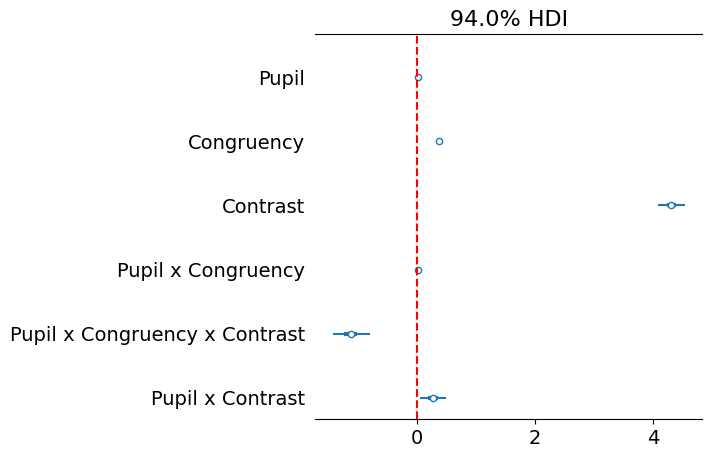

In [10]:
variables_to_plot = [
    "pupil_mean_z", 
    "is_congruent", 
    "np.abs(signed_contrast)",
    "pupil_mean_z:is_congruent",
    "pupil_mean_z:is_congruent:np.abs(signed_contrast)",
    "pupil_mean_z:np.abs(signed_contrast)"
]

fig,ax = plt.subplots(figsize=(5,5))
az.plot_forest(
results,
combined=True, 
var_names=variables_to_plot,
hdi_prob=0.94,
ax=ax,
)
current_labels = [tick.get_text() for tick in ax.get_yticklabels()]
new_labels = [label_map.get(raw_name, raw_name) for raw_name in current_labels]
ax.axvline(0, color='red', linestyle='--')
ax.set_yticklabels(new_labels)

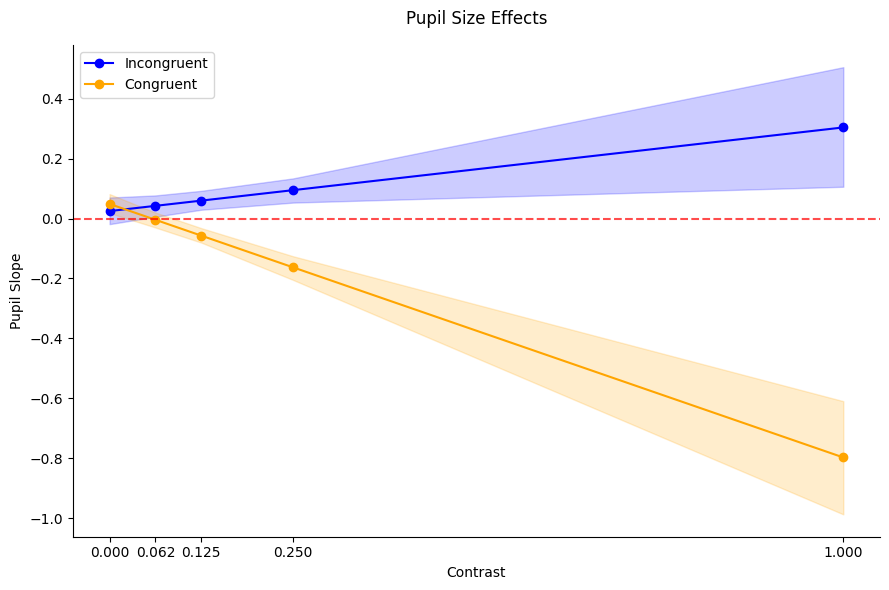

In [11]:
post = results.posterior
b_pupil = post["pupil_mean_z"].values.flatten()
b_pupil_contrast = post["pupil_mean_z:np.abs(signed_contrast)"].values.flatten()
b_pupil_congruency = post["pupil_mean_z:is_congruent"].values.flatten()
b_pupil_3way = post["pupil_mean_z:is_congruent:np.abs(signed_contrast)"].values.flatten()


probe_contrasts = np.array([0.0, 0.0625, 0.125, 0.25, 1.0])


mean_inc, lower_inc, upper_inc = [], [], []
mean_con, lower_con, upper_con = [], [], []


for c in probe_contrasts:

    slope_inc = b_pupil + (b_pupil_contrast * c)
    mean_inc.append(slope_inc.mean())
    hdi_i = az.hdi(slope_inc, hdi_prob=0.94)  # Get the 94% uncertainty interval
    lower_inc.append(hdi_i[0])
    upper_inc.append(hdi_i[1])
    
    slope_con = b_pupil + (b_pupil_contrast * c) + (b_pupil_congruency * 1) + (b_pupil_3way * 1 * c)
    mean_con.append(slope_con.mean())
    hdi_c = az.hdi(slope_con, hdi_prob=0.94)
    lower_con.append(hdi_c[0])
    upper_con.append(hdi_c[1])


fig, ax = plt.subplots(figsize=(9, 6))


ax.plot(probe_contrasts, mean_inc, label='Incongruent', color='blue', marker='o')
ax.fill_between(probe_contrasts, lower_inc, upper_inc, color='blue', alpha=0.2)

ax.plot(probe_contrasts, mean_con, label='Congruent', color='orange', marker='o')
ax.fill_between(probe_contrasts, lower_con, upper_con, color='orange', alpha=0.2)

# Styling
ax.set_title("Pupil Size Effects", pad=15)
ax.set_xlabel("Contrast")
ax.set_ylabel("Pupil Slope")
ax.axhline(0, color='red', linestyle='--', alpha=0.7)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks([0,0.0625,0.125,0.25,1])
plt.tight_layout()
plt.show()

In [12]:
# plot by groups now

plot_df = df.copy()

plot_df['Congruency'] = plot_df['is_congruent'].map({1: 'Congruent', 0: 'Incongruent'})
plot_df['Outcome'] = plot_df['feedback_binary'].map({1: 'Correct', 0: 'Error'})
plot_df['Contrast'] = np.abs(plot_df['signed_contrast'])

plot_df = plot_df.dropna(subset=['pupil_mean_z', 'Outcome', 'Congruency', 'Contrast'])

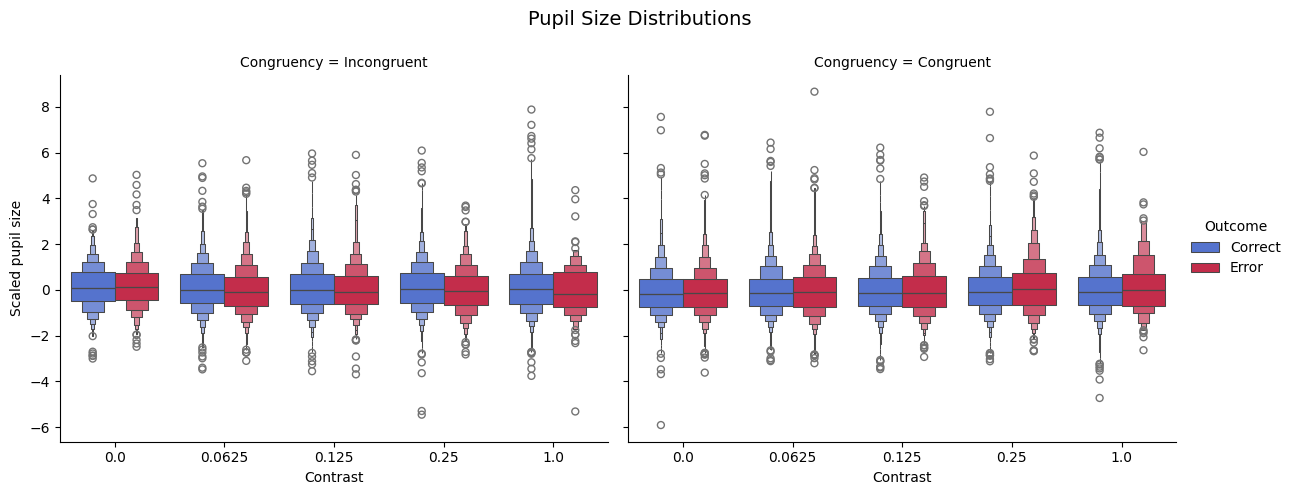

In [13]:
g = sns.catplot(
    data=plot_df,
    x='Contrast', 
    y='pupil_mean_z', 
    hue='Outcome', 
    col='Congruency', 
    kind='boxen',
    # split=True,           # This merges the Correct/Error halves together!
    # inner="quart",        # Draws dotted lines for the 25%, 50%, and 75% quartiles
    palette={"Correct": "royalblue", "Error": "crimson"},
    height=5, 
    aspect=1.2
)

g.set_axis_labels("Contrast", "Scaled pupil size")
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Pupil Size Distributions", fontsize=14)

plt.show()

In [17]:
# how to link this back to engagement/stimulus modulation and prior strength.

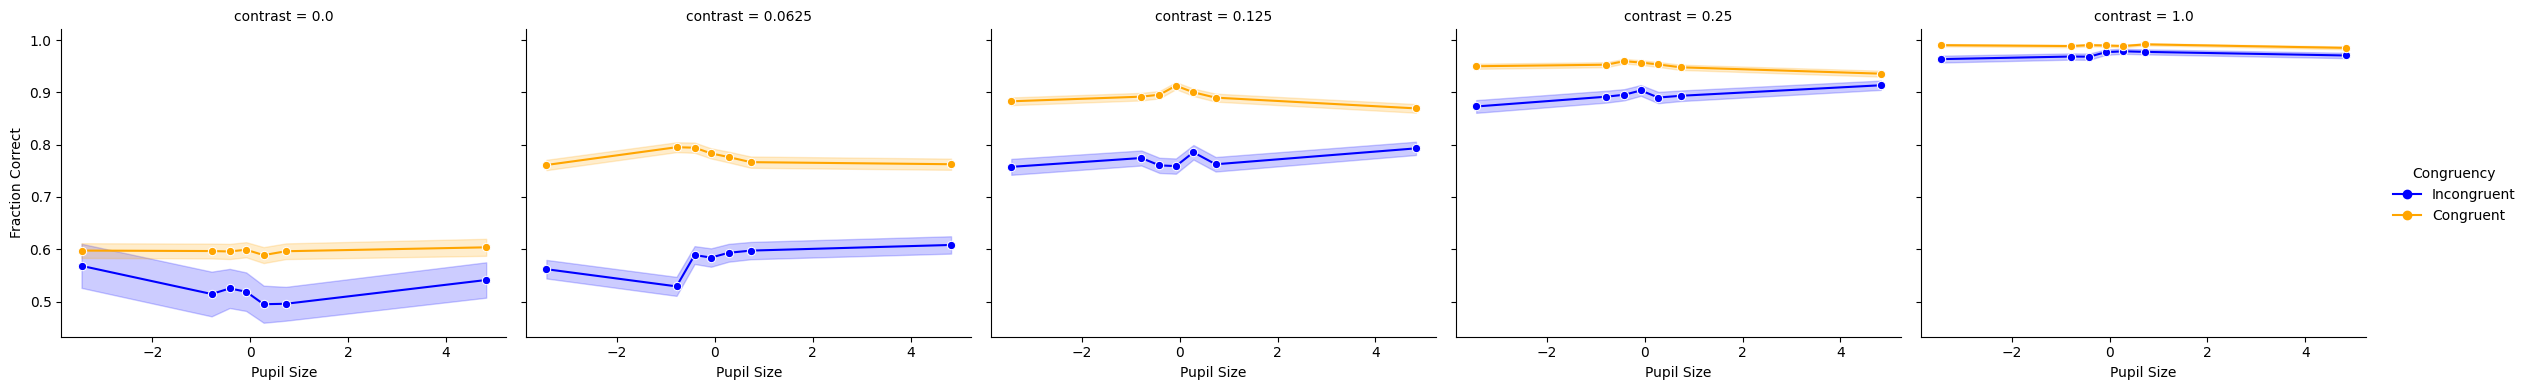

In [22]:
plot_df = df.dropna(subset=['pupil_mean_z', 'feedback_binary', 'is_congruent', 'signed_contrast']).copy()
plot_df['contrast'] = np.abs(plot_df['signed_contrast'])
plot_df['Congruency'] = plot_df['is_congruent'].map({1: 'Congruent', 0: 'Incongruent'})

# Filter to a few key contrasts to keep the plot readable
# plot_df = plot_df[plot_df['contrast'].isin([0.0, 0.125, 1.0])]


plot_df['pupil_bin'] = pd.qcut(plot_df['pupil_mean_z'], q=7)
plot_df['pupil_bin_mid'] = plot_df['pupil_bin'].apply(lambda x: x.mid).astype(float)

g = sns.relplot(
    data=plot_df,
    x='pupil_bin_mid',
    y='feedback_binary',
    hue='Congruency',
    col='contrast',
    kind='line',
    marker='o',
    errorbar='se', # Standard error ribbons around the dots
    palette={'Congruent': 'orange', 'Incongruent': 'blue'},
    height=4,
    aspect=1.2
)

g.set_axis_labels("Pupil Size", "Fraction Correct")
plt.show()



### interaction between action kernel prior strength, engagement and pupil-size

In [8]:
# load the dfs
# do the joins
# and then what, we see?
# we also need to normalize everything 
import pickle as pkl

In [9]:
complete_df = pd.read_parquet('../data/generated/pupilometry/complete_pupil_df.pqt')

In [16]:
# zscore the pupil and motivation_scalar

In [10]:
complete_df.columns

Index(['goCueTrigger_times', 'intervals_bpod_0', 'intervals_bpod_1',
       'quiescencePeriod', 'stimOff_times', 'firstMovement_times',
       'goCue_times', 'probabilityLeft', 'response_times', 'feedbackType',
       'rewardVolume', 'contrastRight', 'choice', 'feedback_times',
       'stimOn_times', 'contrastLeft', 'intervals_0', 'intervals_1',
       'p_state1', 'p_state2', 'signed_contrast', 'rewarded', 'akernel_prior',
       'pe_right', 'motivation_scalar', 'pupil_mean', 'pupil_std',
       'first_movement_time', 'response', 'eid', 'stimOnTrigger_times'],
      dtype='object')

In [12]:
def clean_df_zscored(df):    
    df = df.copy()
    df['pupil_mean_z'] = df.groupby('eid')['pupil_mean'].transform(lambda x: (x - x.mean()) / x.std())
    df['motivation_scaled'] = df.groupby('eid')['motivation_scalar'].transform(lambda x: (x-x.mean())/x.std())

    condition_left_congruent = (df['probabilityLeft'] == 0.8) & (df['signed_contrast'] >= 0)
    condition_right_congruent = (df['probabilityLeft'] == 0.2) & (df['signed_contrast'] <= 0)
    df['is_congruent'] = (condition_left_congruent | condition_right_congruent).astype(int)
    df['feedback_binary'] = (df['feedbackType'] == 1.0).astype(int)
    df['abs_contrast'] = np.abs(df['signed_contrast'])
    return df

In [13]:
transformed_df = clean_df_zscored(complete_df)

In [15]:
# inc_trials['abs_contrast'].unique()
transformed_df['confidence'] = np.abs(transformed_df['akernel_prior']-0.5)

In [16]:
formula_global = "feedback_binary ~ is_congruent * motivation_scaled * confidence + C(abs_contrast) + (1|eid)"

model_phase1_global = bmb.Model(
    formula_global, 
    data=transformed_df, # Now safe to use the full dataset
    family="bernoulli",
    dropna=True
)
idata_phase1 = model_phase1_global.fit(draws=2000, chains=4, target_accept=0.9)

Modeling the probability that feedback_binary==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, is_congruent, motivation_scaled, is_congruent:motivation_scaled, confidence, is_congruent:confidence, motivation_scaled:confidence, is_congruent:motivation_scaled:confidence, C(abs_contrast), 1|eid_sigma, 1|eid_offset]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 291 seconds.


In [17]:
vars=["is_congruent","motivation_scaled","is_congruent:motivation_scaled","confidence","is_congruent:confidence","motivation_scaled:confidence","is_congruent:motivation_scaled:confidence"]

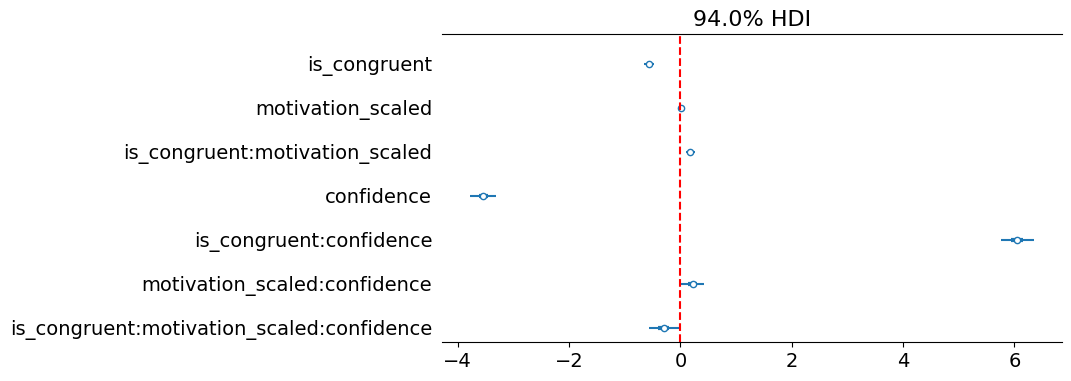

In [18]:
fig, ax = plt.subplots(figsize=(8,4))
az.plot_forest(idata_phase1, var_names=vars, combined=True, ax=ax)
ax.axvline(0,color='r',linestyle='--')

In [ ]:
# just look at incongruent trials

inc_trials = transformed_df[(transformed_df['is_congruent']==False) &  (transformed_df['abs_contrast'] > 0)].copy()
conc_trials = transformed_df[(transformed_df['is_congruent']==True) &  (transformed_df['abs_contrast'] > 0)].copy()


In [83]:
model_phase1 = bmb.Model(
    "feedback_binary ~ motivation_scaled * confidence + C(abs_contrast) + (1|eid)", 
    data=inc_trials, 
    family="bernoulli",
    dropna=True
)
idata_phase1 = model_phase1.fit(draws=2000, chains=4, target_accept=0.9)


Modeling the probability that feedback_binary==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, motivation_scaled, confidence, motivation_scaled:confidence, C(abs_contrast), 1|eid_sigma, 1|eid_offset]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 49 seconds.


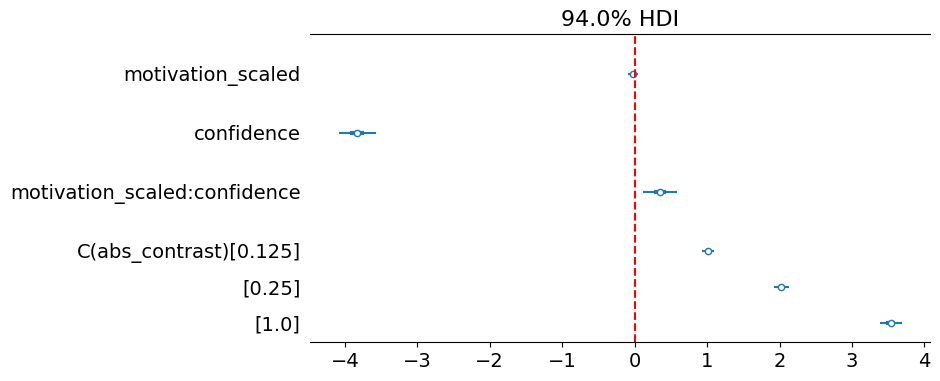

In [84]:
fig, ax = plt.subplots(figsize=(8,4))
az.plot_forest(idata_phase1, var_names=["motivation_scaled", "confidence", "motivation_scaled:confidence", "C(abs_contrast)"], combined=True, ax=ax)
ax.axvline(0,color='r',linestyle='--')


<Axes: xlabel='att_bin', ylabel='confidence_bin'>

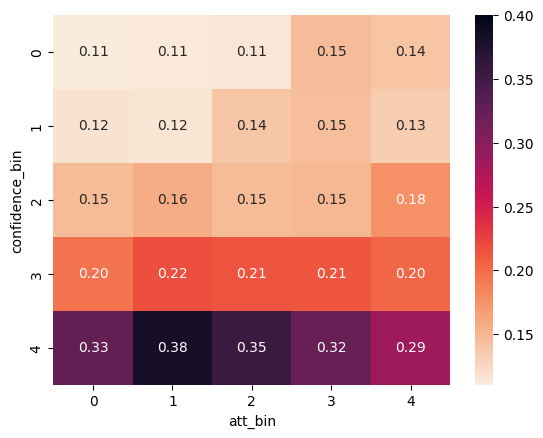

In [26]:
inc_trials['att_bin'] = pd.qcut(inc_trials['motivation_scaled'], q=5, labels=False, duplicates='drop')
inc_trials['confidence_bin'] = pd.qcut(inc_trials['confidence'], q=5, labels=False, duplicates='drop')
inc_trials['error'] = 1-inc_trials['feedback_binary']
heatmap_data = inc_trials.groupby(['confidence_bin', 'att_bin'])['error'].mean().unstack()
sns.heatmap(
    heatmap_data, 
    annot=True, 
    cmap='rocket_r', 
    fmt=".2f", 
    vmax=0.4
)


In [21]:
# what about congruence
model_phase2 = bmb.Model(
    "feedback_binary ~ motivation_scaled * confidence + C(abs_contrast) + (1|eid)", 
    data=conc_trials, 
    family="bernoulli",
    dropna=True
)
idata_phase2 = model_phase2.fit(draws=2000, chains=4, target_accept=0.9)


Modeling the probability that feedback_binary==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, motivation_scaled, confidence, motivation_scaled:confidence, C(abs_contrast), 1|eid_sigma, 1|eid_offset]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 99 seconds.


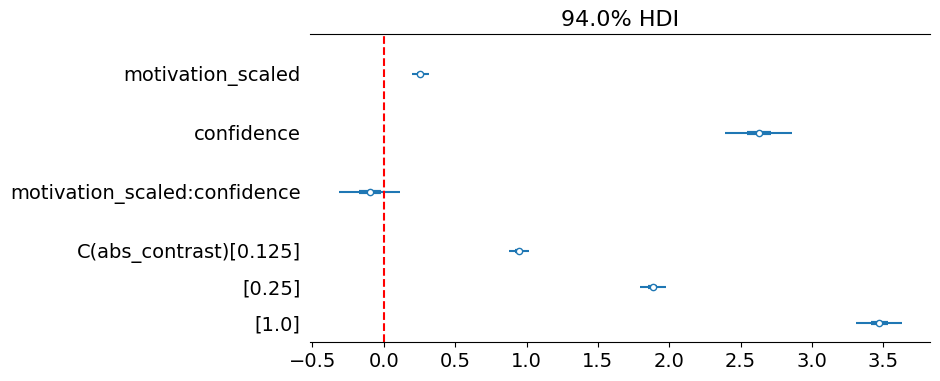

In [22]:
fig, ax = plt.subplots(figsize=(8,4))
az.plot_forest(idata_phase2, var_names=["motivation_scaled", "confidence", "motivation_scaled:confidence", "C(abs_contrast)"], combined=True, ax=ax)
ax.axvline(0,color='r',linestyle='--')


<Axes: xlabel='att_bin', ylabel='confidence_bin'>

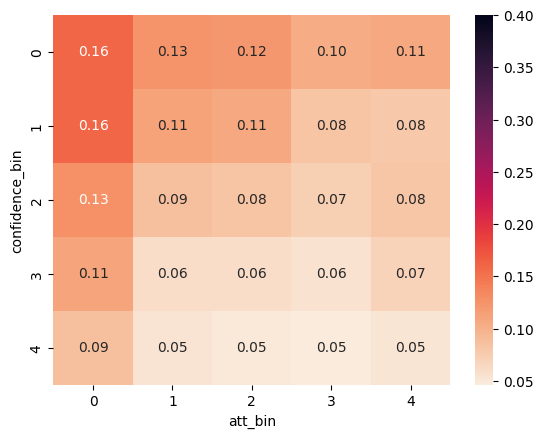

In [27]:
conc_trials['att_bin'] = pd.qcut(conc_trials['motivation_scaled'], q=5, labels=False, duplicates='drop')
conc_trials['confidence_bin'] = pd.qcut(conc_trials['confidence'], q=5, labels=False, duplicates='drop')
conc_trials['error'] = 1-conc_trials['feedback_binary']
heatmap_data = conc_trials.groupby(['confidence_bin', 'att_bin'])['error'].mean().unstack()
sns.heatmap(
    heatmap_data, 
    annot=True, 
    cmap='rocket_r', 
    fmt=".2f", 
    vmax=0.4
)


In [28]:
# okay, so we kind of see what we expected
# now to link pupil size to this


In [29]:
# link with pupil - how?

In [30]:
# look at pupil vs prior confidence and motivation scalar.

In [69]:
def plot_pupil_size_distributions(plot_trials,condition):


    g_mot = sns.catplot(
        data=plot_trials, 
        x='motivation_bin', 
        y='pupil_mean_z', 
        hue='feedback_binary',
        col='abs_contrast',      
        kind='point',            
        estimator="median", 
        errorbar=('ci', 95), 
        dodge=True, 
        palette={1: '#2ca02c', 0: '#d62728'},
        height=5,                
        aspect=0.8               
    )

    g_mot.fig.suptitle(f"Median pupil size vs Motivation : {condition}", y=1.05)
    g_mot.set_axis_labels("Motivation", "Scaled pupil size")
    g_mot.set_titles("Contrast: {col_name}") 
    plt.show()

    g_conf = sns.catplot(
        data=plot_trials, 
        x='confidence_bin', 
        y='pupil_mean_z', 
        hue='feedback_binary',
        col='abs_contrast',   
        kind='point', 
        estimator="median", 
        errorbar=('ci', 95), 
        dodge=True, 
        palette={1: '#2ca02c', 0: '#d62728'},
        height=5, 
        aspect=0.8
    )

    g_conf.fig.suptitle(f"Median pupil size vs Confidence : {condition}", y=1.05)
    g_conf.set_axis_labels("Confidence", "Scaled pupil size")
    g_conf.set_titles("Contrast: {col_name}")
    plt.show()

In [94]:

qvalue = 4
qlabels = [f'Q{idx+1}' for idx in range(qvalue)]

inc_trials['motivation_bin'] = pd.qcut(inc_trials['motivation_scaled'], q=qvalue, labels=qlabels)
inc_trials['confidence_bin'] = pd.qcut(inc_trials['confidence'], q=qvalue, labels=qlabels)

plot_trials_incongruent = inc_trials.copy()
plot_trials_incongruent = plot_trials_incongruent.reset_index(drop=True)

conc_trials['motivation_bin'] = pd.qcut(conc_trials['motivation_scaled'], q=qvalue, labels=qlabels)
conc_trials['confidence_bin'] = pd.qcut(conc_trials['confidence'], q=qvalue, labels=qlabels)

plot_trials_congruent = conc_trials.copy()
plot_trials_congruent = plot_trials_congruent.reset_index()

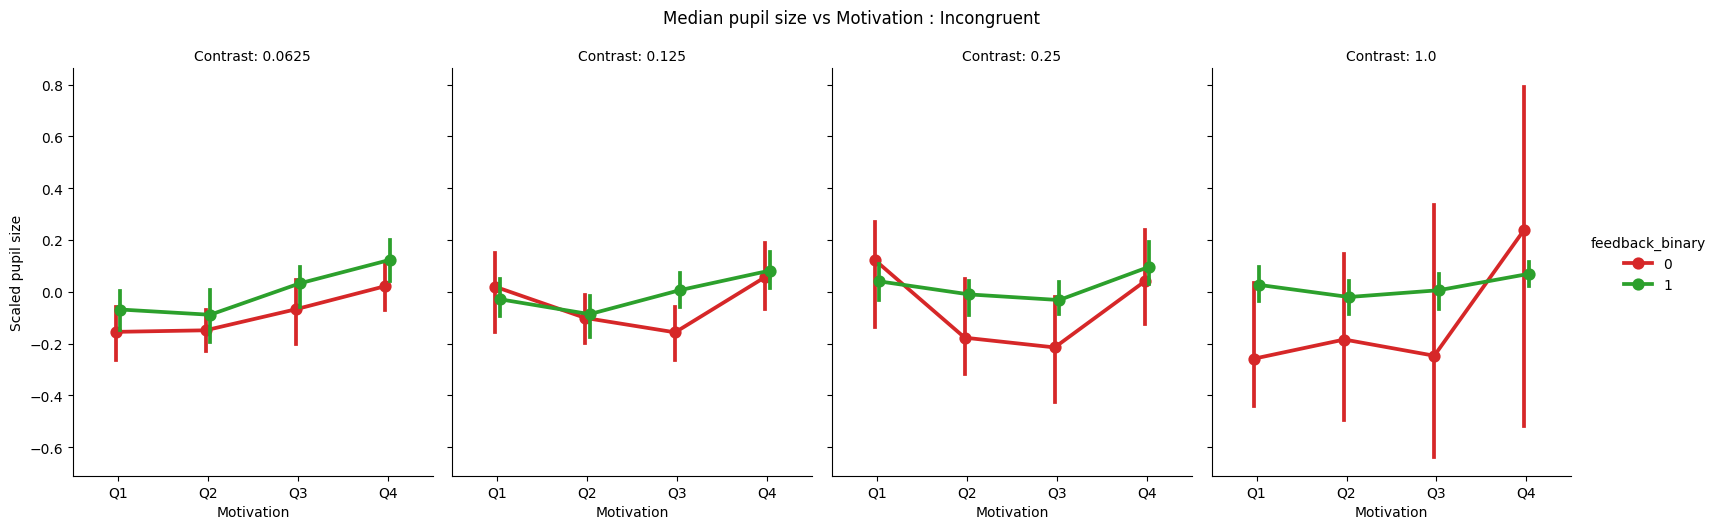

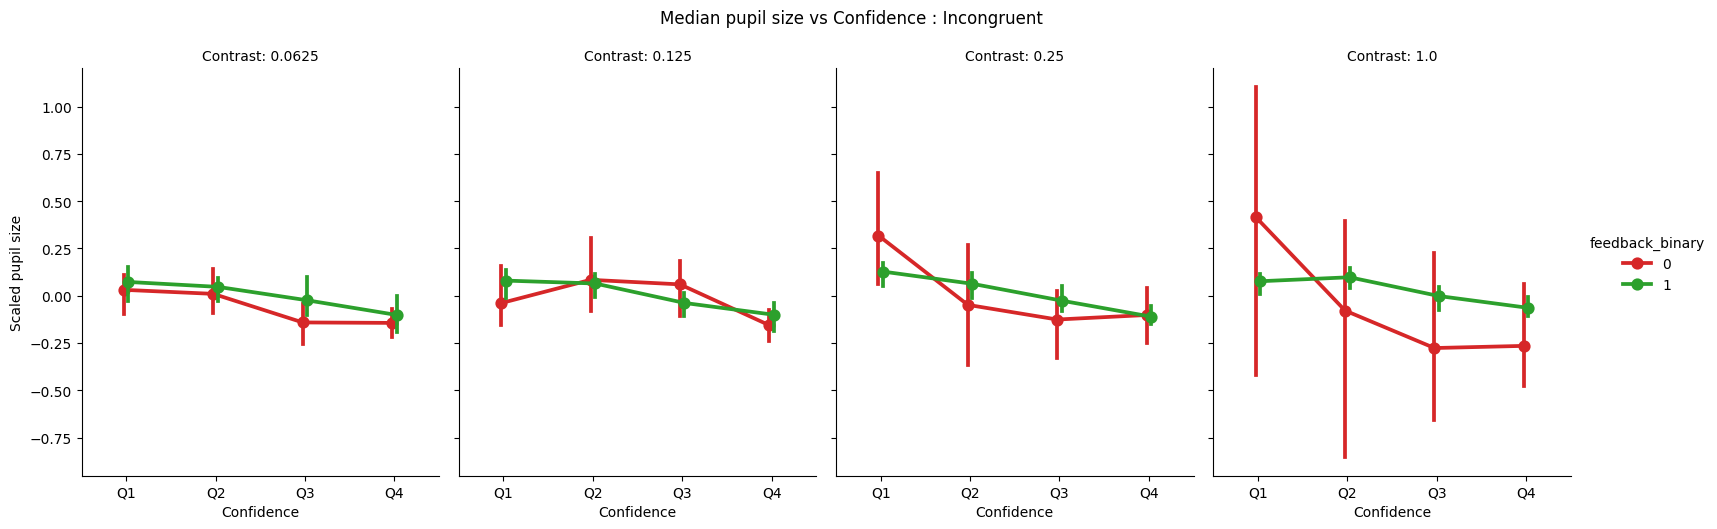

In [95]:
plot_pupil_size_distributions(plot_trials_incongruent, "Incongruent")

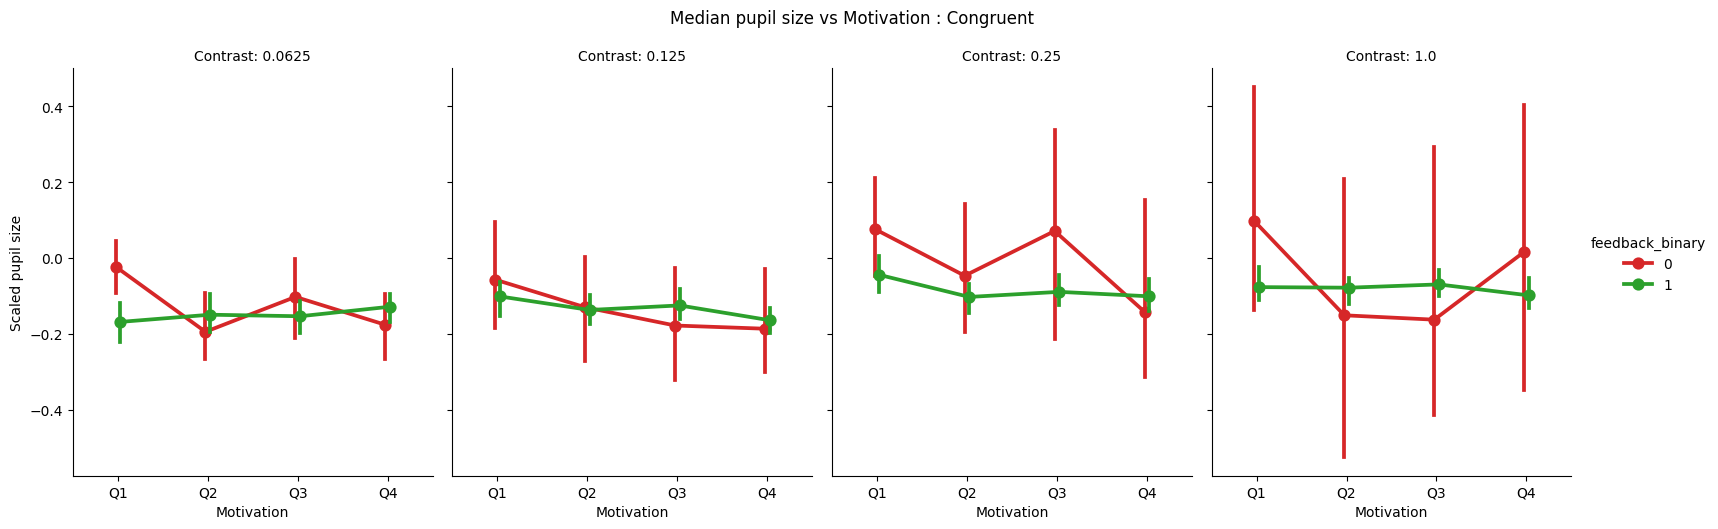

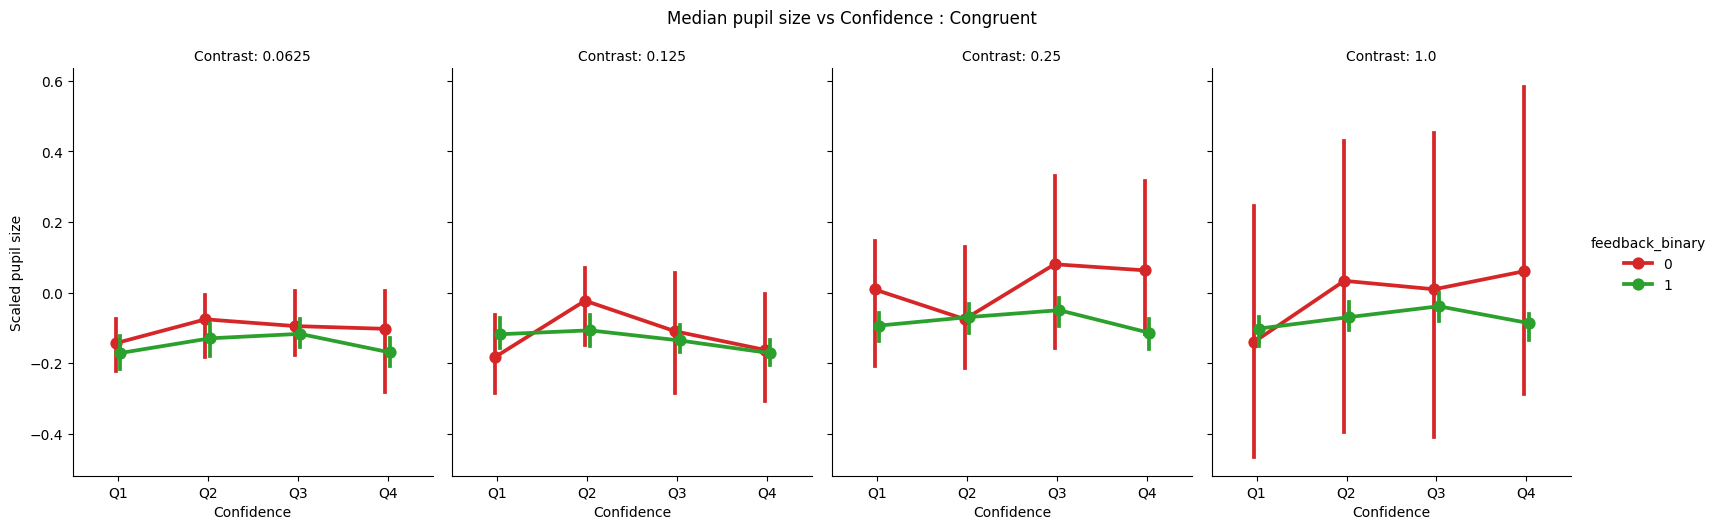

In [96]:
plot_pupil_size_distributions(plot_trials_congruent, "Congruent")

In [99]:
def plot_aggregate(session_medians_motivation, session_medians_confidence, condition):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)


    sns.pointplot(
        data=session_medians_motivation, 
        x='motivation_bin', 
        y='pupil_mean_z', 
        hue='feedback_binary',
        estimator="median",     # Calculates the overall median across sessions
        errorbar=('ci', 95), 
        dodge=True, 
        palette={1: '#2ca02c', 0: '#d62728'}, 
        ax=axes[0],
    )
    axes[0].set_title("Pupil size vs Motivation")
    axes[0].set_ylabel("Scaled pupil size")
    axes[0].set_xlabel("Motivation")
    # axes[0].legend(['Incorrect','Correct'])

    sns.pointplot(
        data=session_medians_confidence, 
        x='confidence_bin', 
        y='pupil_mean_z', 
        hue='feedback_binary',
        estimator="median", 
        errorbar=('ci', 95), 
        dodge=True, 
        palette={1: '#2ca02c', 0: '#d62728'}, 
        ax=axes[1],
        legend=False
    )
    axes[1].set_title("Pupil size vs Confidence")
    axes[1].set_ylabel("") # Share Y axis
    axes[1].set_xlabel("Confidence")
    sns.despine()
    plt.suptitle(f'{condition}')
    
    plt.show()

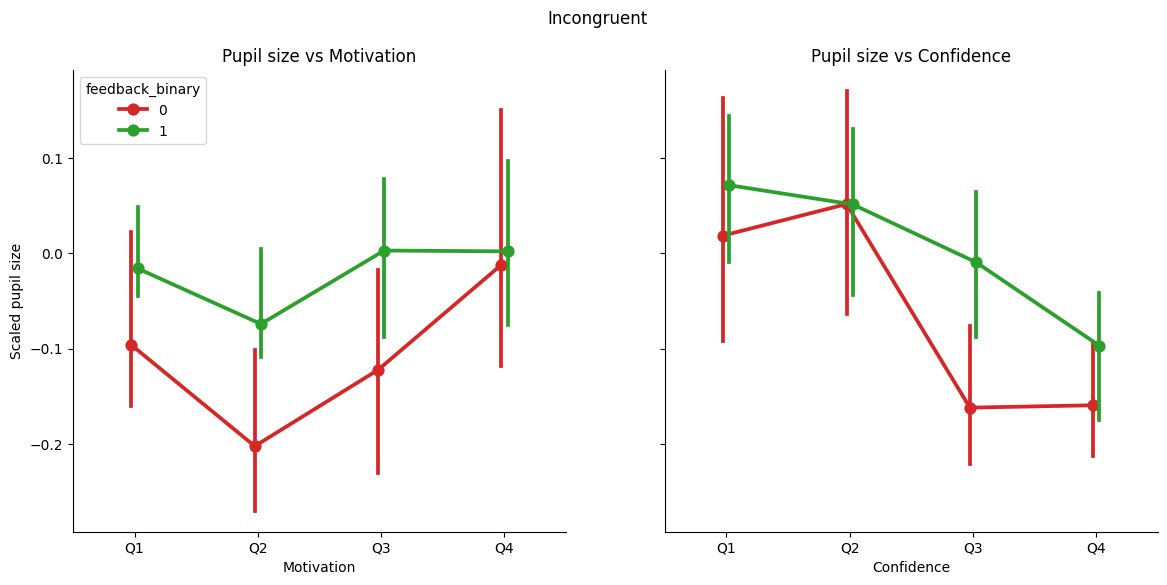

In [100]:
session_medians_mot = plot_trials_incongruent.groupby(
    ['eid', 'motivation_bin', 'feedback_binary'],
    observed=True
)['pupil_mean_z'].median().reset_index().dropna()

session_medians_conf = plot_trials_incongruent.groupby(
    ['eid', 'confidence_bin', 'feedback_binary'],
    observed=True
)['pupil_mean_z'].median().reset_index().dropna()

plot_aggregate(session_medians_mot, session_medians_conf, condition='Incongruent')


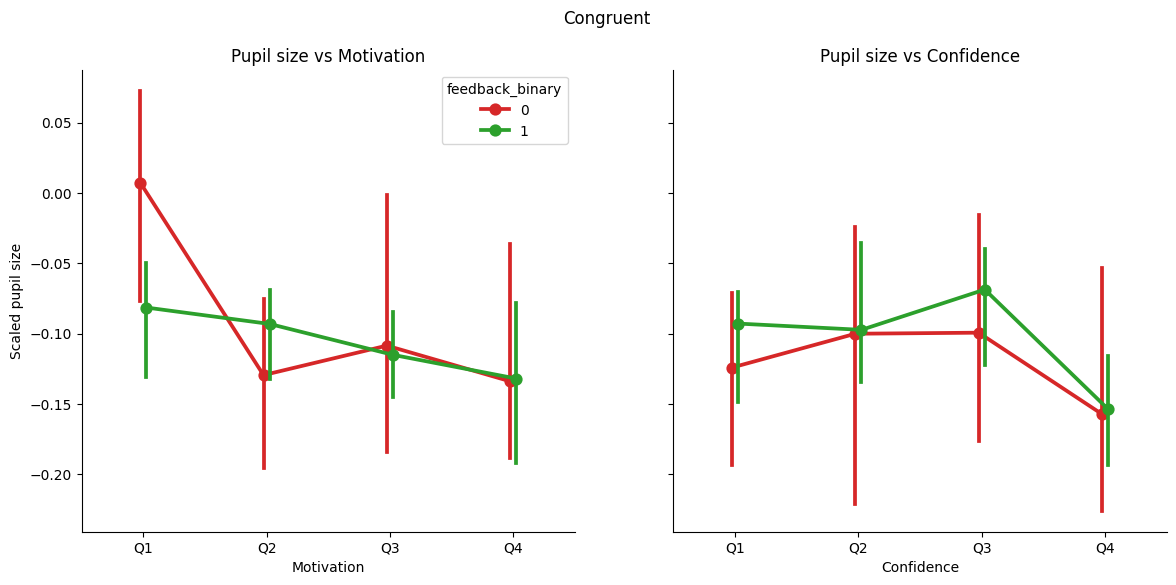

In [101]:
session_medians_mot = plot_trials_congruent.groupby(
    ['eid', 'motivation_bin', 'feedback_binary'],
    observed=True
)['pupil_mean_z'].median().reset_index().dropna()

session_medians_conf = plot_trials_congruent.groupby(
    ['eid', 'confidence_bin', 'feedback_binary'],
    observed=True
)['pupil_mean_z'].median().reset_index().dropna()

plot_aggregate(session_medians_mot, session_medians_conf, condition='Congruent')


In [20]:
formula_pupil_global = "pupil_mean_z ~ is_congruent * feedback_binary * (confidence + motivation_scaled) + (1|eid)"

model_pupil_global = bmb.Model(formula_pupil_global, data=transformed_df, dropna=True)
results_pupil_global = model_pupil_global.fit(draws=2000, chains=4)

Automatically removing 457/85976 rows from the dataset.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, is_congruent, feedback_binary, is_congruent:feedback_binary, confidence, motivation_scaled, is_congruent:confidence, is_congruent:motivation_scaled, feedback_binary:confidence, feedback_binary:motivation_scaled, is_congruent:feedback_binary:confidence, is_congruent:feedback_binary:motivation_scaled, 1|eid_sigma, 1|eid_offset]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 159 seconds.


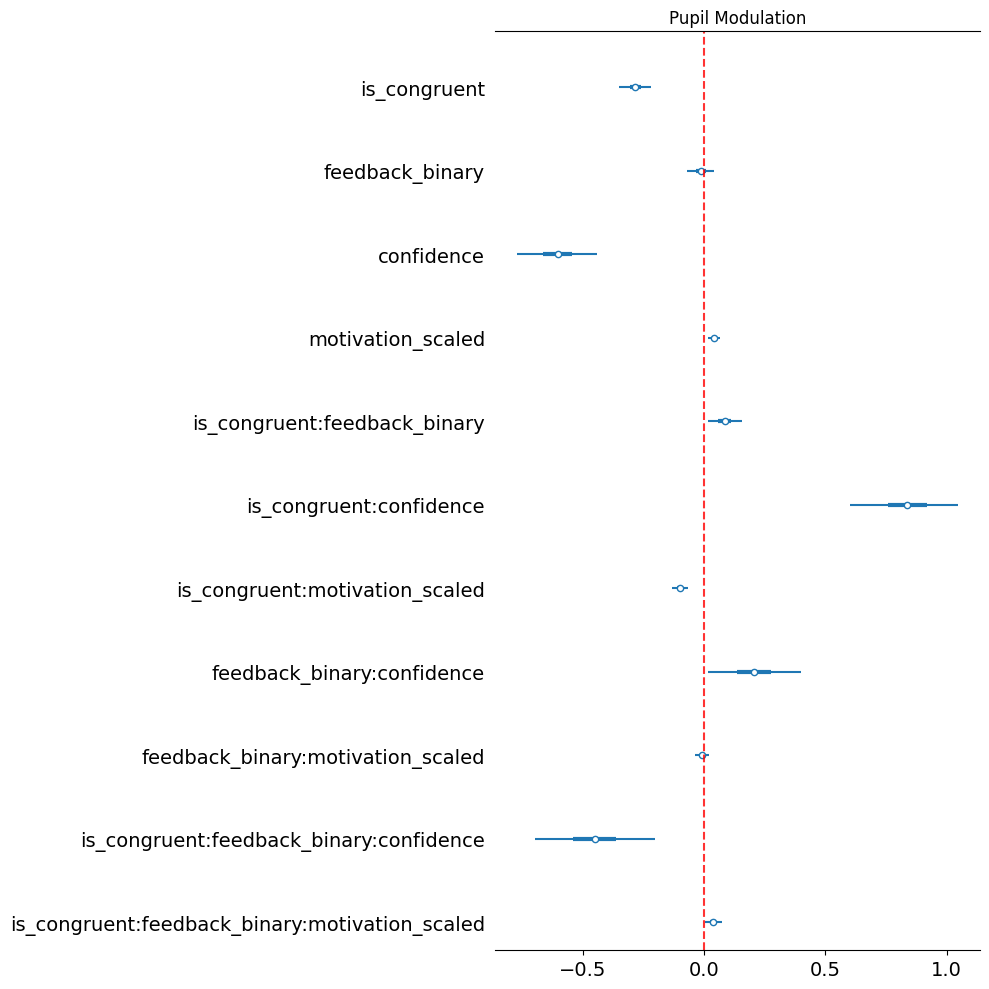

In [22]:
relevant_vars = [
    "is_congruent",
    "feedback_binary",
    "confidence",
    "motivation_scaled",
    "is_congruent:feedback_binary",
    "is_congruent:confidence",
    "is_congruent:motivation_scaled",
    "feedback_binary:confidence",
    "feedback_binary:motivation_scaled",
    "is_congruent:feedback_binary:confidence",
    "is_congruent:feedback_binary:motivation_scaled"
]

# 3. Plot the forest plot
fig, ax = plt.subplots(figsize=(10, 10))

az.plot_forest(
    results_pupil_global,
    var_names=relevant_vars,
    combined=True,       # Combines all 4 MCMC chains into one robust distribution
    hdi_prob=0.94,       # Standard 94% HDI
    ax=ax
)

plt.title("Pupil Modulation")
plt.axvline(0, color='red', linestyle='--', alpha=0.8) 
plt.tight_layout()
plt.show()